### Langchain Version V1

In [25]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [26]:
def get_weather(city: str) -> str:
    """Get the weather in a city."""
    return f"The weather in {city} is sunny."

In [27]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen2.5",
    temperature=0,
)

In [28]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant.",
)

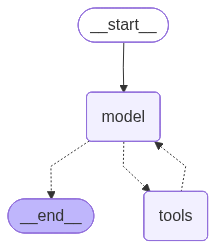

In [29]:
agent

In [38]:
### run the agent

response = agent.invoke({"messages": [{"role":"user", "content":"What is india famous for?"}]})

In [40]:
response["messages"]

[HumanMessage(content='What is india famous for?', additional_kwargs={}, response_metadata={}, id='d60239d4-e952-4358-840e-2f07d16e1c5c'),
 AIMessage(content="India is famous for its rich cultural heritage, diverse cuisine, ancient history, and vibrant traditions. It's also known for its contributions to spirituality, yoga, and Ayurveda. Additionally, India has a thriving IT industry and is home to many world-renowned companies. Would you like me to elaborate on any specific aspect?", additional_kwargs={}, response_metadata={'model': 'qwen2.5', 'created_at': '2026-02-25T06:24:17.8412073Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6701861284, 'load_duration': 3573369205, 'prompt_eval_count': 149, 'prompt_eval_duration': 374922285, 'eval_count': 66, 'eval_duration': 2488719595, 'logprobs': None, 'model_name': 'qwen2.5', 'model_provider': 'ollama'}, id='lc_run--019c9378-277e-7a31-84fc-7448048cc5b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 149,

### Tools

Models can request to call tools that perform tasks such as fetching data from databases, searching the web, or running code. Tools are pairings of:

    1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
    2. A function or coroutine to execute.

In [54]:
from langchain.tools import tool

@tool
def get_weather_of_a_location(location:str) -> str:
    """Get the weather for a location"""
    return f"The weather in {location} is rainy."


model_with_tools = llm.bind_tools([get_weather_of_a_location])

In [55]:
response = model_with_tools.invoke("What's the weather like in Boston?")

In [56]:
response

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5', 'created_at': '2026-02-26T09:11:01.004536418Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4861583941, 'load_duration': 3531953500, 'prompt_eval_count': 164, 'prompt_eval_duration': 374599732, 'eval_count': 23, 'eval_duration': 831118664, 'logprobs': None, 'model_name': 'qwen2.5', 'model_provider': 'ollama'}, id='lc_run--019c9937-2d8a-7821-aa98-679a24ae84fa-0', tool_calls=[{'name': 'get_weather_of_a_location', 'args': {'location': 'Boston'}, 'id': 'b5e1f0d2-d7cf-497e-bcab-f0939e6ec467', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 164, 'output_tokens': 23, 'total_tokens': 187})

In [57]:
for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

Tool: get_weather_of_a_location
Args: {'location': 'Boston'}


### Tool Execution Loops

In [58]:
messages = [{"role": "user", "content": "What's the weather in Bangalore?"}]

ai_msg = model_with_tools.invoke(messages)

messages.append(ai_msg)

messages

[{'role': 'user', 'content': "What's the weather in Bangalore?"},
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5', 'created_at': '2026-02-26T09:11:08.341698837Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1476611916, 'load_duration': 323214040, 'prompt_eval_count': 163, 'prompt_eval_duration': 130826940, 'eval_count': 24, 'eval_duration': 883220814, 'logprobs': None, 'model_name': 'qwen2.5', 'model_provider': 'ollama'}, id='lc_run--019c9937-576c-7041-9268-5cdaff373b69-0', tool_calls=[{'name': 'get_weather_of_a_location', 'args': {'location': 'Bangalore'}, 'id': '4ec26fa6-daa1-413d-b055-0b79c005f4f8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 163, 'output_tokens': 24, 'total_tokens': 187})]

In [ ]:
for tool_call in ai_msg.tool_calls:
    print(tool_call)
    tool_result = get_weather_of_a_location.invoke(tool_call)
    messages.append(tool_result) 

messages

{'name': 'get_weather_of_a_location', 'args': {'location': 'Bangalore'}, 'id': '4ec26fa6-daa1-413d-b055-0b79c005f4f8', 'type': 'tool_call'}


[{'role': 'user', 'content': "What's the weather in Bangalore?"},
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5', 'created_at': '2026-02-26T09:11:08.341698837Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1476611916, 'load_duration': 323214040, 'prompt_eval_count': 163, 'prompt_eval_duration': 130826940, 'eval_count': 24, 'eval_duration': 883220814, 'logprobs': None, 'model_name': 'qwen2.5', 'model_provider': 'ollama'}, id='lc_run--019c9937-576c-7041-9268-5cdaff373b69-0', tool_calls=[{'name': 'get_weather_of_a_location', 'args': {'location': 'Bangalore'}, 'id': '4ec26fa6-daa1-413d-b055-0b79c005f4f8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 163, 'output_tokens': 24, 'total_tokens': 187}),
 ToolMessage(content='The weather in Bangalore is rainy.', name='get_weather_of_a_location', tool_call_id='4ec26fa6-daa1-413d-b055-0b79c005f4f8')]

### Pydantic Structured Output

In [64]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title:str=Field(description="The title of the movie")
    year:int=Field(description="This year the movie was released")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The movies rating out of 10")

In [65]:
model_with_structure=llm.with_structured_output(Movie)

In [66]:
model_with_structure

RunnableBinding(bound=ChatOllama(model='qwen2.5', temperature=0.0), kwargs={'format': {'properties': {'title': {'description': 'The title of the movie', 'title': 'Title', 'type': 'string'}, 'year': {'description': 'This year the movie was released', 'title': 'Year', 'type': 'integer'}, 'director': {'description': 'The director of the movie', 'title': 'Director', 'type': 'string'}, 'rating': {'description': 'The movies rating out of 10', 'title': 'Rating', 'type': 'number'}}, 'required': ['title', 'year', 'director', 'rating'], 'title': 'Movie', 'type': 'object'}, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema'}, 'schema': <class '__main__.Movie'>}}, config={}, config_factories=[])
| PydanticOutputParser(pydantic_object=<class '__main__.Movie'>)

In [67]:
model_with_structure.invoke("Provide the details of the movie Inception")

Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8)

### Message output alongside parsed structure

In [ ]:
model_with_structure=llm.with_structured_output(Movie, include_raw=True)

In [68]:
model_with_structure.invoke("Provide the details of the movie Inception")

Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8)

In [70]:
class Actor(BaseModel):
    name:str
    role:str

class MovieDetails(BaseModel):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description="Budget in million USD")

In [72]:
model_with_structure = llm.with_structured_output(MovieDetails)

In [73]:
response = model_with_structure.invoke("Provide details about the movie")

In [74]:
response

MovieDetails(title='Inception', year=2010, cast=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Elliot Page', role='Ariadne'), Actor(name='Tom Hardy', role='Eames')], genres=['Action', 'Sci-Fi', 'Thriller'], budget=160000000.0)